# ====================================
# 📊 Hopify Retention Curve Plot
# ====================================

## ====================================
## Import Libraries & Setup Base Path
## ====================================

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# 📁 Set Base Path to Project Root
# ================================

try:
    BASE_PATH = os.path.abspath(os.path.join(os.path.dirname(__file__), "..", "..", ".."))
except NameError:
    # Jupyter or interactive context
    BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))

print("📁 Base path set to:", BASE_PATH)


## ============================================
## Set File Path & Load Dataframe
## ============================================

In [6]:
file_path = os.path.join(
    BASE_PATH,
    "01_project_artifacts",
    "02_sql_output",
    "01_project_churn_retention_analysis",
    "07_hopify_retention_curve_signup_cohort.csv"
)

df = pd.read_csv(file_path)

# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("%", "percent")
    .str.replace("-", "_")
    .str.lower()
)

# Rename for clarity
df.rename(columns={
    "signup_cohort_month": "cohort",
    "months_since_signup": "month",
    "retention_percent": "retention"
}, inplace=True)

# Parse cohort as string to avoid datetime x-axis
df["cohort"] = df["cohort"].astype(str)

## ====================================
## 🔍 Filter to Most Recent 8 Cohorts
## ====================================

In [7]:
recent_cohorts = df["cohort"].drop_duplicates().sort_values(ascending=False).head(8)
df_filtered = df[df["cohort"].isin(recent_cohorts)]

most_recent = recent_cohorts.iloc[0]
df_recent = df_filtered[df_filtered["cohort"] == most_recent]
df_others = df_filtered[df_filtered["cohort"] != most_recent]

## ============================
## Plot Retention Decay Curve
## ============================

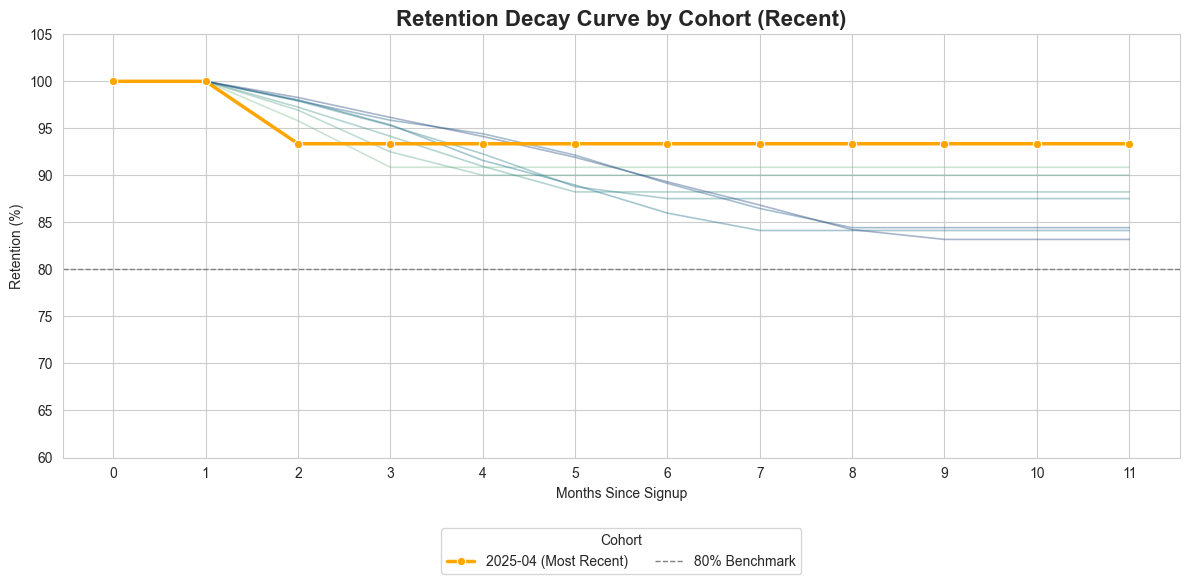

In [8]:
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Plot all other cohorts faintly
sns.lineplot(
    data=df_others,
    x="month",
    y="retention",
    hue="cohort",
    palette="crest",
    linewidth=1.2,
    alpha=0.4,
    legend=False
)

# Highlight most recent cohort
sns.lineplot(
    data=df_recent,
    x="month",
    y="retention",
    color="orange",
    linewidth=2.5,
    marker="o",
    label=f"{most_recent} (Most Recent)"
)

# Add benchmark
plt.axhline(80, color='gray', linestyle='--', linewidth=1, label="80% Benchmark")

# Format chart
plt.title("Retention Decay Curve by Cohort (Recent)", fontsize=16, fontweight="bold")
plt.xlabel("Months Since Signup")
plt.ylabel("Retention (%)")
plt.xticks(range(df_filtered["month"].max() + 1))
plt.ylim(60, 105)
plt.legend(title="Cohort", loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.tight_layout()